# Explore multithreading

Testing the 1B BF16 model, unoptimised, starting from `8264f62`.

Methods:
 - Single threaded
 - Local OpenMP - wrap `matmulT` outer loop in `#pragma omp parallel for`
 - Global OpenMP - put most of `forward` in a `#pragma omp parallel` and use `#pragma omp for` in each op
 - Manual threads - start N `std::thread`, divide work evenly, use `std::barrier` to synchronize

In [34]:
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
matplotlib.rcParams.update({"axes.spines.top": False, "axes.spines.right": False, "legend.frameon": False})

## Host (x86 laptop with 8 cores x 2 hyperthreads)

```sh
echo "" | ./dev run -- cli ../models/Llama-3.2-1B-Instruct-BF16.sqt -g16
```

,gen_rate
method,
manual,9.713333
omp_global,9.610000
omp_local,9.400000
single,1.793333


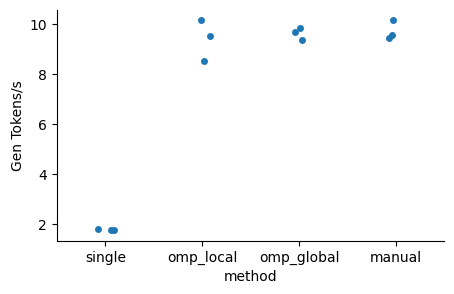

In [41]:
# host (16 threads)
df = pd.DataFrame.from_dict(dict(
    single=[1.83, 1.77, 1.78],
    omp_local=[10.15, 8.53, 9.52],
    omp_global=[9.34, 9.67, 9.82],
    manual=[10.15, 9.45, 9.54],
)).melt(var_name="method", value_name="gen_rate")
display(df.groupby("method").mean().sort_values("gen_rate", ascending=False))
plt.figure(figsize=(5, 3))
ax = sns.stripplot(df, y="gen_rate", x="method")
ax.set_ylabel("Gen Tokens/s");

## Android (Pixel 8a with 1 + 4 + 4 cores)

CPU: Nona-core (1 x 3.0 GHz Cortex-X3 & 4 x 2.45 GHz Cortex-A715 & 4 x 2.15 GHz Cortex-A510)

```sh
echo "" | ./dev -p android run -- cli Llama-3.2-1B-Instruct-BF16.sqt -g16
```

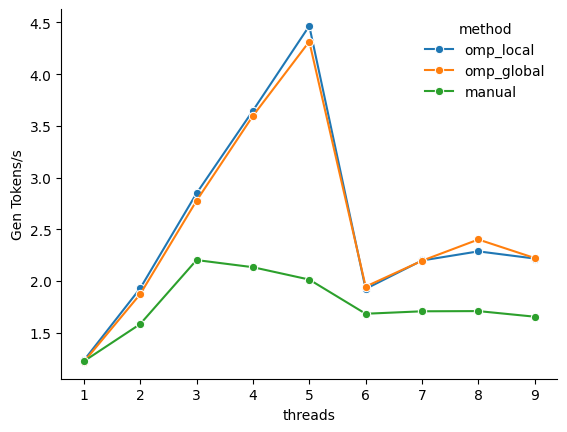

In [42]:
df = (pd.DataFrame.from_records([
    [1, 1.23285, 1.21903, 1.22529],
    [2, 1.92988, 1.87374, 1.58481],
    [3, 2.84833, 2.77676, 2.20335],
    [4, 3.64708, 3.59638, 2.1343],
    [5, 4.46581, 4.3148 , 2.01472],
    [6, 1.92494, 1.94709, 1.68448],
    [7, 2.19913, 2.19672, 1.70824],
    [8, 2.28732, 2.40211, 1.71016],
    [9, 2.21794, 2.22291, 1.656],
], columns=["threads", "omp_local", "omp_global", "manual"])
    .melt(id_vars=["threads"], var_name="method", value_name="gen_rate"))
ax = sns.lineplot(df, y="gen_rate", x="threads", hue="method", marker="o")
ax.set_ylabel("Gen Tokens/s");

This indicates that the optimal threading scheme for this (presumably) memory-bound task is to use the 1 + 4 BIG cores, but avoid creating enough threads to be scheduled on little.

We also see that the manual scheme does not perform well here - perhaps this is because it doesn't have any way to dynamically rebalance work, and is pre-locked into an equal amount of work per worker thread. This is not a good match for heteregeneous cores.